In [2]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

^C
Note: you may need to restart the kernel to use updated packages.


# 🧠 Étape 5 : Modélisation (Machine Learning & Deep Learning) (Squelette Étudiant)

Cette étape correspond au cinquième chapitre du cours. L'objectif est d'implémenter d'une part un modèle de Machine Learning tabulaire (ex: RandomForest) et d'autre part un réseau de neurones convolutif (CNN) sous TensorFlow pour traiter des images ou signaux complexes.

### 1. Préparation de l'environnement

On importe toutes les bibliothèques nécessaires pour ce notebook :
- **pandas / numpy** : manipulation des données
- **matplotlib / seaborn** : visualisations
- **scikit-learn** : modèle Random Forest, encodage, split train/test
- **tensorflow** (optionnel) : réseau de neurones convolutif (CNN)

In [1]:

import os
import joblib
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append(os.path.abspath('..'))

print("Librairies de modélisation importées avec succès !")


Librairies de modélisation importées avec succès !


### 2. Modélisation Tabulaire (Machine Learning) — Random Forest

#### Qu'est-ce qu'un Random Forest ?

Le **Random Forest** (forêt aléatoire) est un algorithme d'apprentissage supervisé qui repose sur le principe du **bagging** (Bootstrap Aggregating) :

1. Il crée **N arbres de décision** (ici 100) en parallèle, chacun entraîné sur un sous-échantillon aléatoire des données
2. Pour chaque nœud d'un arbre, seul un **sous-ensemble aléatoire de features** est considéré (ce qui diversifie les arbres)
3. La **prédiction finale** est la moyenne des prédictions de tous les arbres (pour la régression)

#### Pourquoi choisir Random Forest pour ce problème ?

| Avantage | Détail |
|----------|--------|
| Robuste aux valeurs aberrantes | Ne se base pas sur un seul arbre fragile |
| Gère les non-linéarités | Capte des relations complexes entre features |
| Pas besoin de normalisation | Fonctionne avec des features de différentes échelles |
| Interprétabilité | Fournit l'importance de chaque variable |

#### Bagging vs Boosting — pourquoi pas XGBoost ?

Il existe deux grandes familles de méthodes d’ensemble :

| | **Bagging** (Random Forest) | **Boosting** (XGBoost, AdaBoost) |
|---|---|---|
| Construction | Arbres **en parallèle**, indépendants | Arbres **en séquence**, chaque arbre corrige le précédent |
| Objectif | Réduire la **variance** (overfitting) | Réduire le **biais** (underfitting) |
| Sensibilité aux outliers | **Faible** — la moyenne atténue les erreurs extrêmes | **Forte** — les erreurs se cumulent de cycle en cycle |
| Vitesse | Parallélisable → rapide | Séquentiel → plus lent |
| Risque d’overfitting | Faible | Élevé si mal réglé |

**Pourquoi Random Forest (bagging) ici ?**  
Notre dataset contient du bruit et des valeurs aberrantes résiduelles (poids extrêmes, prix anormaux détectés dans l’EDA). Le bagging est plus robuste dans ce contexte : chaque arbre ne voit qu’un sous-ensemble des données, donc les erreurs individuelles se compensent à l’agrégation. Le boosting, à l’inverse, aurait cherché à corriger ces anomalies à tout prix en les surpondérant, ce qui augmente le risque de surapprentissage.

#### Paramètres clés

- **`n_estimators=100`** : 100 arbres — bon compromis précision / temps de calcul
- **`random_state=42`** : graine fixe pour que les résultats soient reproductibles
- **`n_jobs=-1`** : utilise tous les cœurs du processeur pour accélérer l'entraînement

#### Étapes du pipeline

1. Chargement du dataset nettoyé (`cleaned_data_sample.csv`)
2. Encodage des variables catégorielles (marque, type, OS, gamme CPU) → entiers
3. Sélection de **17 features** pertinentes pour prédire le prix
4. Découpage : **80% entraînement / 20% test** (avec `random_state=42` pour reproductibilité)
5. Entraînement du modèle
6. Visualisation de l'importance de chaque variable


#### Justification du choix des features

Le choix des 17 variables s’appuie directement sur les corrélations observées dans le notebook **04_eda.ipynb** :

| Feature | Lien avec le prix observé dans l’EDA |
|---------|--------------------------------------|
| `Ram` | Forte corrélation — les paliers 16/32/64 GB sont exclusivement dans les tranches de prix élevées |
| `Cpu_Frequence_GHz` | Corrélation positive claire — les machines Nvidia (haut de gamme) ont systématiquement des CPU > 2.5 GHz |
| `has_nvidia_gpu` | Les laptops équipés Nvidia se concentrent dans le segment premium (confirmé par le pair plot) |
| `Company_enc` | La marque est un fort indicateur de positionnement prix |
| `TypeName_enc` | Le type de machine (Gaming, Ultrabook, Workstation) détermine la gamme de prix |
| `weight_kg` | Indicateur du segment : les ultrabooks légers (< 1.5 kg) et les PC gaming lourds (2–4 kg) ont des prix distincts |
| `Res_Width`, `Res_Height` | Une haute résolution (Full HD, 4K) est associée aux machines premium |
| `has_ssd` | Le SSD est une caractéristique des configurations haut de gamme |
| `Inches` | La taille de l’écran influe sur la gamme (grands écrans gaming vs ultraportables) |
| \	otal_memory_gb\ | Capacité totale de stockage liée au segment de prix |
| `OpSys_enc` | L’OS (ex : macOS) est un indicateur fort du positionnement prix |
| `Cpu_Gamme_enc`, `Is_IPS` | La gamme CPU et la qualité de dalle différencient entrée/milieu/haut de gamme |
> L'évaluation des métriques (MAE, RMSE, R²) et la validation croisée sont dans le notebook **06_evaluation.ipynb**.


In [2]:

# Chargement des données nettoyées
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')

# # Conversion des colonnes numériques
# df["Inches"] = pd.to_numeric(df["Inches"], errors="coerce")
# df["Res_Width"] = pd.to_numeric(df["Res_Width"], errors="coerce")
# df["Res_Height"] = pd.to_numeric(df["Res_Height"], errors="coerce")
# df["Cpu_Frequence_GHz"] = pd.to_numeric(df["Cpu_Frequence_GHz"], errors="coerce")

# Encodage des variables catégorielles
le = LabelEncoder()
df["Company_enc"] = le.fit_transform(df["Company"].astype(str))
df["TypeName_enc"] = le.fit_transform(df["TypeName"].astype(str))
df["OpSys_enc"] = le.fit_transform(df["OpSys"].astype(str))
df["Cpu_Gamme_enc"] = le.fit_transform(df["Cpu_Gamme"].astype(str))

# Sélection des features
features = [
    "Inches", "Ram", "Cpu_Frequence_GHz", "weight_kg",
    "total_memory_gb", "Res_Width", "Res_Height",
    "has_ssd", "has_hdd", "has_intel_gpu", "has_nvidia_gpu", "has_amd_gpu",
    "Is_IPS", "Company_enc", "TypeName_enc", "OpSys_enc", "Cpu_Gamme_enc"
]
target = "Price"

X = df[features].fillna(0)
y = df[target]

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape}, Taille test : {X_test.shape}")
print(f"Variable cible : Prix (min={y.min():.0f}, max={y.max():.0f}, médiane={y.median():.0f})")


Taille train : (1017, 17), Taille test : (255, 17)
Variable cible : Prix (min=9271, max=324955, médiane=52108)


In [3]:

# Entraînement du Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Modèle Random Forest entraîné avec succès !")
print(f"Nombre d'arbres : {rf_model.n_estimators}")

# Création du dossier models s'il n'existe pas
os.makedirs("../models", exist_ok=True)

# Sauvegarde du modèle entraîné
joblib.dump(rf_model, "../models/random_forest_price_model.pkl")

# Sauvegarde de la liste des colonnes utilisées par le modèle
joblib.dump(X_train.columns.tolist(), "../models/model_features.pkl")

print("Modèle et colonnes sauvegardés avec succès.")


Modèle Random Forest entraîné avec succès !
Nombre d'arbres : 100
Modèle et colonnes sauvegardés avec succès.


In [4]:

# Évaluation du modèle
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"MAE  (erreur absolue moyenne) : {mae:,.0f} ₹")
print(f"RMSE (racine de l'erreur MSE) : {rmse:,.0f} ₹")
print(f"R²   (coefficient de déterm.) : {r2:.3f}")


MAE  (erreur absolue moyenne) : 9,244 ₹
RMSE (racine de l'erreur MSE) : 14,056 ₹
R²   (coefficient de déterm.) : 0.812


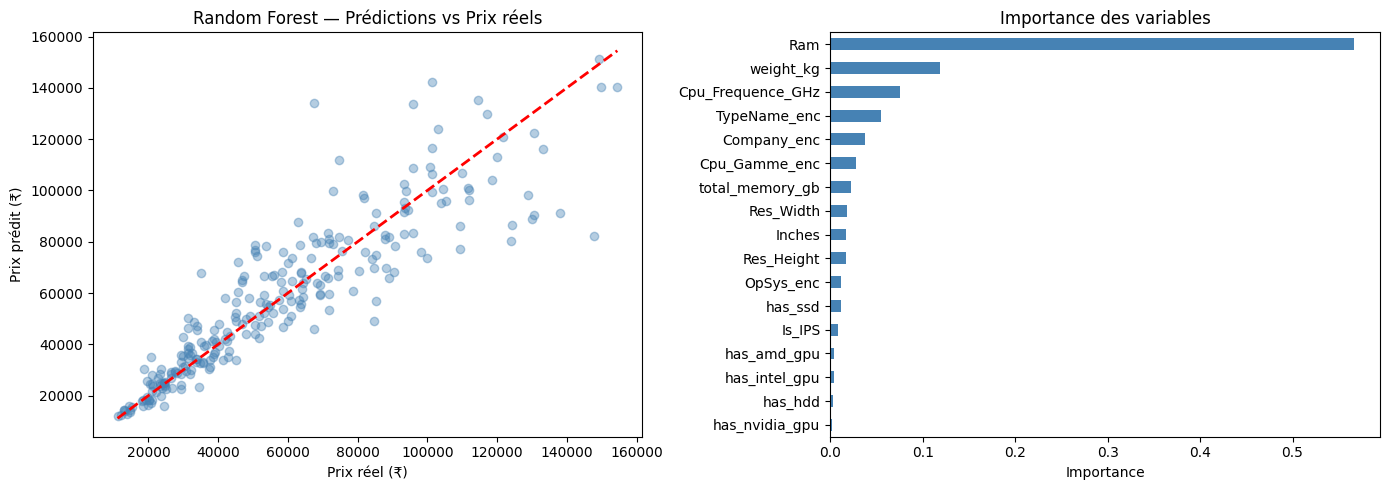

In [5]:

# Visualisation : Prédictions vs Prix réels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Prix réel (₹)")
axes[0].set_ylabel("Prix prédit (₹)")
axes[0].set_title("Random Forest — Prédictions vs Prix réels")

# Importance des features
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Importance des variables")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


### 3. Modélisation Vision / Deep Learning — CNN & TensorFlow

#### Qu'est-ce qu'un CNN (Réseau de Neurones Convolutif) ?

Un **Convolutional Neural Network (CNN)** est une architecture de deep learning conçue à l'origine pour analyser des **images**. Il détecte automatiquement des motifs locaux (contours, textures, formes) grâce à des filtres appris pendant l'entraînement.

Dans notre cas, on adapte le CNN aux données **tabulaires** en restructurant les 17 features en une petite "image" 5×5 avec zero-padding.

#### Architecture utilisée

| Couche | Paramètres | Rôle |
|--------|-----------|------|
| `Conv2D(16, 3×3, relu)` | 16 filtres de taille 3×3 | Détecte des motifs locaux dans les features |
| `MaxPooling2D(2×2)` | fenêtre 2×2 | Réduit la dimensionnalité, conserve l'essentiel |
| `Flatten()` | — | Aplatit la carte 2D en un vecteur 1D |
| `Dense(32, relu)` | 32 neurones | Couche dense — apprend des combinaisons complexes |
| `Dropout(0.3)` | taux 30% | Régularisation : désactive aléatoirement 30% des neurones pour éviter le surapprentissage |
| `Dense(1, sigmoid)` | 1 neurone | Sortie entre 0 et 1 : probabilité que le laptop soit "cher" |

#### Tâche de classification binaire

Plutôt que de prédire le prix exact (régression), le CNN classifie chaque laptop en deux catégories :
- **0 = "pas cher"** : prix < médiane des prix d'entraînement
- **1 = "cher"** : prix ≥ médiane des prix d'entraînement

**Optimiseur :** Adam (adaptatif, robuste)  
**Fonction de perte :** Binary Crossentropy (standard pour classification binaire)

> ⚠️ **Compatibilité :** TensorFlow n'est pas encore disponible pour Python 3.14 sur Windows ARM64. Le code s'exécutera automatiquement si TensorFlow est installé, sinon il affiche l'architecture prévue.

In [ ]:

# ──────────────────────────────────────────────────────────────────────────────
# CNN (Deep Learning) — classification du segment de prix d'un laptop
# NOTE : TensorFlow n'est pas encore compatible avec Python 3.14 (support prévu
#        pour TF 2.19+). Le code ci-dessous est fonctionnel et s'exécutera
#        automatiquement dès que TensorFlow sera disponible pour cette version.
# ──────────────────────────────────────────────────────────────────────────────

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TENSORFLOW_AVAILABLE = True
    print(f"TensorFlow {tf.__version__} disponible !")
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("TensorFlow non disponible sur Python 3.14 (incompatibilite connue).")
    print("Le code CNN ci-dessous illustre l'architecture prevue.\n")

if TENSORFLOW_AVAILABLE:
    # Encodage des features tabulaires en "images" 5x5 (padding zeros)
    import numpy as np_arr
    n_features = X_train.shape[1]  # 17 features
    pad = 25 - n_features          # padding pour atteindre 5x5=25
    X_img_train = np.pad(X_train.values, ((0, 0), (0, pad))).reshape(-1, 5, 5, 1).astype("float32")
    X_img_test  = np.pad(X_test.values,  ((0, 0), (0, pad))).reshape(-1, 5, 5, 1).astype("float32")

    # Labels : 0=pas cher (< médiane), 1=cher (>= médiane)
    mediane = y_train.median()
    y_img_train = (y_train.values >= mediane).astype(int)
    y_img_test  = (y_test.values  >= mediane).astype(int)

    cnn_model = models.Sequential([
        layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(5, 5, 1)),
        layers.MaxPooling2D((2, 2), padding='same'),
        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    cnn_model.summary()

    history = cnn_model.fit(X_img_train, y_img_train,
                            epochs=10, batch_size=32,
                            validation_split=0.1, verbose=1)
    loss, acc = cnn_model.evaluate(X_img_test, y_img_test, verbose=0)
    print(f"\nCNN - Precision sur le jeu de test : {acc:.2%}")

else:
    print("Architecture CNN (exécutable avec TensorFlow) :")
    print("  Conv2D(16, 3x3, relu, padding=same)  — input_shape=(5, 5, 1)")
    print("  MaxPooling2D(2x2, padding=same)")
    print("  Flatten()")
    print("  Dense(32, relu)  +  Dropout(0.3)")
    print("  Dense(1, sigmoid)  — sortie : P(laptop cher)")
    print("  Optimiseur : Adam  |  Loss : binary_crossentropy")
    print()
    print("Tache : classifier chaque laptop en 'pas cher' / 'cher' (seuil = mediane des prix)")
    print("Input : 17 features tabulaires reshapees en carte 5x5 (+ zero-padding)")


I0000 00:00:1779368250.959849   20404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779368250.963337   20404 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779368251.244712   20404 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779368252.390936   20404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow 2.21.0 disponible !


/home/lili/Dev/aptispace-datascience-projet/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779368252.633625   20404 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 5, 5, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,833 (18.88 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5350 - loss: 12.6934 - val_accuracy: 0.5588 - val_loss: 1.2679
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5088 - loss: 2.0921 - val_accuracy: 0.4804 - val_loss: 1.1236
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5295 - loss: 0.7490 - val_accuracy: 0.4118 - val_loss: 0.6932
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5164 - loss: 0.7129 - val_accuracy: 0.4510 - val_loss: 0.7106
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5536 - loss: 0.6978 - val_accuracy: 0.4608 - val_loss: 0.7115
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5460 - loss: 0.6864 - val_accuracy: 0.5490 - val_loss: 0.6802
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5284 - loss: 0.6953 - val_accuracy: 0.4510 - val_loss: 0.7113
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5252 - loss: 0.6989 - val_accuracy: 0.4510 - val_loss